# Layout transform overhead analysis

Analyze `base_t32-llama2_7b_layout_fused_seq_sweep/raw_db.csv` and `base_t8-llama2_7b_layout_fused_seq_sweep/raw_db.csv`, then compare baseline kernels against layout-fused kernels for the same `(fpga, op, batch, seq, M, K)` shape.

- Baseline: `rmsnorm`, `silu`
- Layout fused: `rms_norm_layout_fused`, `silu_layout_fused`
- Main metric: `avg_us`
- Overhead: `fused_avg_us - baseline_avg_us`, and `fused_avg_us / baseline_avg_us - 1`


In [8]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

DATASETS = {
    # 'base_t32': Path('/home/jaeyongjang/project.local/vortex/build/results/latency/base_t32-llama2_7b_layout_fused_seq_sweep/raw_db.csv'),
    # 'base_t8': Path('/home/jaeyongjang/project.local/vortex/build/results/latency/base_t8-llama2_7b_layout_fused_seq_sweep/raw_db.csv'),
    'improve_tcol1': Path('/home/jaeyongjang/project.local/vortex/build/results/latency/improve_tcol1-llama2_7b_layout_fused_seq_sweep/raw_db.csv')
}

def normalize_op(kind: str) -> str:
    if 'rms' in kind:
        return 'rmsnorm'
    if 'silu' in kind:
        return 'silu'
    return kind

def load_dataset(fpga: str, path: Path) -> pd.DataFrame:
    out = pd.read_csv(path)
    shape = out['shape_json'].apply(json.loads).apply(pd.Series)
    out = pd.concat([out, shape], axis=1)
    out['fpga'] = fpga
    out['op'] = out['kind'].map(normalize_op)
    out['variant_norm'] = out['kind'].map(lambda k: 'layout_fused' if 'layout_fused' in k else 'baseline')
    return out

df = pd.concat([load_dataset(fpga, path) for fpga, path in DATASETS.items()], ignore_index=True)

print(df.shape)
df[['fpga', 'case_id', 'kind', 'op', 'variant_norm', 'batch', 'seq', 'M', 'K', 'avg_us']].head()

(12, 40)


,fpga,case_id,kind,op,variant_norm,batch,seq,M,K,avg_us
0,improve_tcol1,rmsnorm_b1_s512,rmsnorm,rmsnorm,baseline,1.0,512.0,512.0,4096.0,256744.619
1,improve_tcol1,rmsnorm_b1_s8192,rmsnorm,rmsnorm,baseline,1.0,8192.0,8192.0,4096.0,4084913.405
2,improve_tcol1,rmsnorm_b1_s16384,rmsnorm,rmsnorm,baseline,1.0,16384.0,16384.0,4096.0,8168593.892
3,improve_tcol1,rms_norm_layout_fused_b1_s512,rms_norm_layout_fused,rmsnorm,layout_fused,1.0,512.0,512.0,4096.0,340107.475
4,improve_tcol1,rms_norm_layout_fused_b1_s8192,rms_norm_layout_fused,rmsnorm,layout_fused,1.0,8192.0,8192.0,4096.0,5420011.950


In [9]:
keys = ['fpga', 'op', 'batch', 'seq', 'M', 'K']
metrics = ['avg_us', 'min_us', 'p50_us', 'p95_us', 'case_id']

base = (
    df[df['variant_norm'] == 'baseline'][keys + metrics]
    .rename(columns={c: f'baseline_{c}' for c in metrics})
)
fused = (
    df[df['variant_norm'] == 'layout_fused'][keys + metrics]
    .rename(columns={c: f'fused_{c}' for c in metrics})
)

paired = base.merge(fused, on=keys, how='inner')
paired['baseline_ms'] = paired['baseline_avg_us'] / 1000
paired['fused_ms'] = paired['fused_avg_us'] / 1000
paired['overhead_us'] = paired['fused_avg_us'] - paired['baseline_avg_us']
paired['overhead_ms'] = paired['overhead_us'] / 1000
paired['overhead_pct'] = paired['overhead_us'] / paired['baseline_avg_us'] * 100
paired['ratio'] = paired['fused_avg_us'] / paired['baseline_avg_us']
paired = paired.sort_values(['fpga', 'op', 'batch', 'seq']).reset_index(drop=True)

display_cols = ['fpga', 'op', 'batch', 'seq', 'M', 'K', 'baseline_ms', 'fused_ms', 'overhead_ms', 'overhead_pct', 'ratio']
paired[display_cols]

,fpga,op,batch,seq,M,K,baseline_ms,fused_ms,overhead_ms,overhead_pct,ratio
0,improve_tcol1,rmsnorm,1.0,512.0,512.0,4096.0,256.744619,340.107475,83.362856,32.469174,1.324692
1,improve_tcol1,rmsnorm,1.0,8192.0,8192.0,4096.0,4084.913405,5420.011950,1335.098545,32.683644,1.326836
2,improve_tcol1,rmsnorm,1.0,16384.0,16384.0,4096.0,8168.593892,10838.824162,2670.230270,32.688983,1.326890
3,improve_tcol1,silu,1.0,512.0,512.0,11008.0,1165.189351,1105.462721,-59.726630,-5.125916,0.948741
4,improve_tcol1,silu,1.0,8192.0,8192.0,11008.0,18631.779449,17663.587428,-968.192021,-5.196455,0.948035
5,improve_tcol1,silu,1.0,16384.0,16384.0,11008.0,37320.817977,35324.808965,-1996.009012,-5.348246,0.946518


In [10]:
summary_by_op = (
    paired.groupby(['fpga', 'op'])
    .agg(
        n=('overhead_pct', 'size'),
        mean_overhead_pct=('overhead_pct', 'mean'),
        median_overhead_pct=('overhead_pct', 'median'),
        min_overhead_pct=('overhead_pct', 'min'),
        max_overhead_pct=('overhead_pct', 'max'),
        mean_overhead_ms=('overhead_ms', 'mean'),
        total_baseline_ms=('baseline_ms', 'sum'),
        total_fused_ms=('fused_ms', 'sum'),
    )
    .reset_index()
)
summary_by_op['aggregate_overhead_pct'] = (
    (summary_by_op['total_fused_ms'] - summary_by_op['total_baseline_ms'])
    / summary_by_op['total_baseline_ms'] * 100
)
summary_by_op

,fpga,op,n,mean_overhead_pct,median_overhead_pct,min_overhead_pct,max_overhead_pct,mean_overhead_ms,total_baseline_ms,total_fused_ms,aggregate_overhead_pct
0,improve_tcol1,rmsnorm,3,32.613933,32.683644,32.469174,32.688983,1362.897224,12510.251916,16598.943587,32.682729
1,improve_tcol1,silu,3,-5.223539,-5.196455,-5.348246,-5.125916,-1007.975888,57117.786777,54093.859114,-5.294196


In [11]:
summary_by_op_batch = (
    paired.groupby(['fpga', 'op', 'batch'])
    .agg(
        n=('overhead_pct', 'size'),
        mean_overhead_pct=('overhead_pct', 'mean'),
        median_overhead_pct=('overhead_pct', 'median'),
        min_overhead_pct=('overhead_pct', 'min'),
        max_overhead_pct=('overhead_pct', 'max'),
        total_baseline_ms=('baseline_ms', 'sum'),
        total_fused_ms=('fused_ms', 'sum'),
    )
    .reset_index()
)
summary_by_op_batch['aggregate_overhead_pct'] = (
    (summary_by_op_batch['total_fused_ms'] - summary_by_op_batch['total_baseline_ms'])
    / summary_by_op_batch['total_baseline_ms'] * 100
)
summary_by_op_batch

,fpga,op,batch,n,mean_overhead_pct,median_overhead_pct,min_overhead_pct,max_overhead_pct,total_baseline_ms,total_fused_ms,aggregate_overhead_pct
0,improve_tcol1,rmsnorm,1.0,3,32.613933,32.683644,32.469174,32.688983,12510.251916,16598.943587,32.682729
1,improve_tcol1,silu,1.0,3,-5.223539,-5.196455,-5.348246,-5.125916,57117.786777,54093.859114,-5.294196


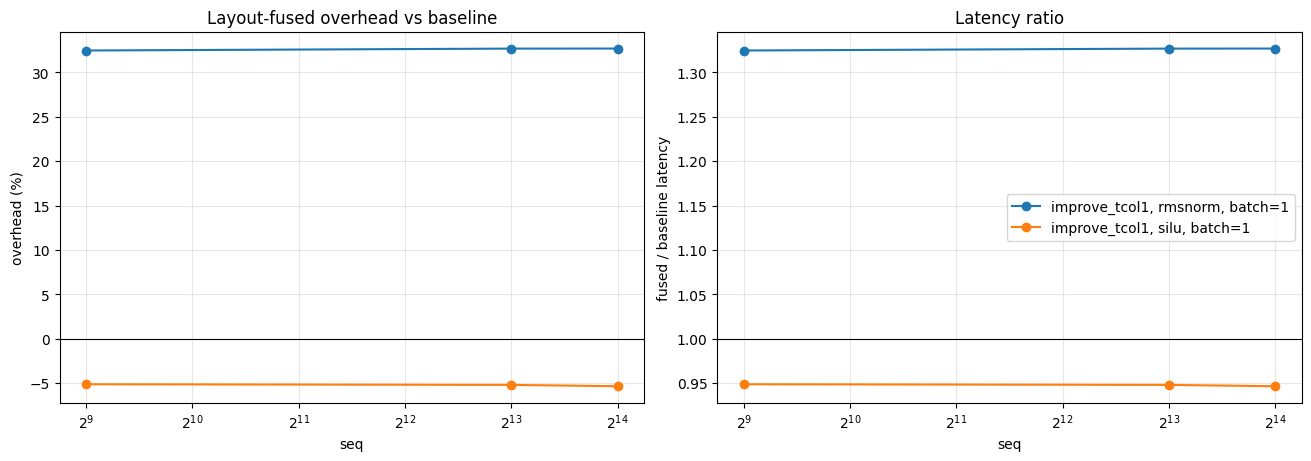

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for (fpga, op, batch), g in paired.groupby(['fpga', 'op', 'batch']):
    label = f'{fpga}, {op}, batch={int(batch)}'
    axes[0].plot(g['seq'], g['overhead_pct'], marker='o', label=label)
    axes[1].plot(g['seq'], g['ratio'], marker='o', label=label)

axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xscale('log', base=2)
axes[0].set_xlabel('seq')
axes[0].set_ylabel('overhead (%)')
axes[0].set_title('Layout-fused overhead vs baseline')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1, color='black', linewidth=0.8)
axes[1].set_xscale('log', base=2)
axes[1].set_xlabel('seq')
axes[1].set_ylabel('fused / baseline latency')
axes[1].set_title('Latency ratio')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.show()

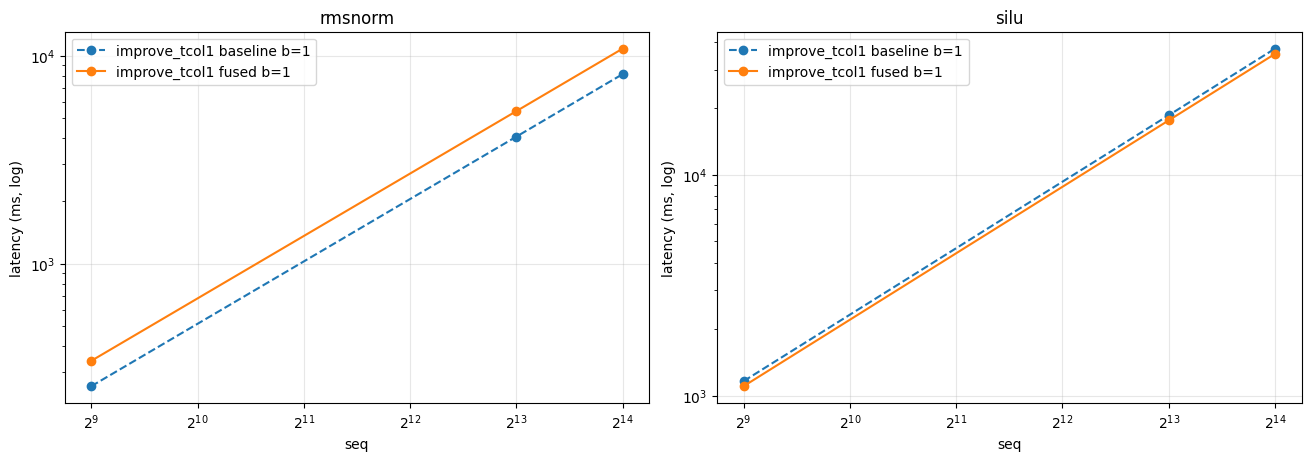

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for op, ax in zip(['rmsnorm', 'silu'], axes):
    gop = paired[paired['op'] == op]
    for (fpga, batch), g in gop.groupby(['fpga', 'batch']):
        ax.plot(g['seq'], g['baseline_ms'], marker='o', linestyle='--', label=f'{fpga} baseline b={int(batch)}')
        ax.plot(g['seq'], g['fused_ms'], marker='o', label=f'{fpga} fused b={int(batch)}')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('seq')
    ax.set_ylabel('latency (ms, log)')
    ax.set_title(op)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.show()

## Cross-FPGA overhead comparison

Compare overhead percentages between `base_t32` and `base_t8` for the same operation and shape.

In [14]:
comparison = paired.pivot_table(
    index=['op', 'batch', 'seq', 'M', 'K'],
    columns='fpga',
    values=['baseline_ms', 'fused_ms', 'overhead_pct', 'ratio'],
    aggfunc='first',
)
comparison.columns = [f'{metric}_{fpga}' for metric, fpga in comparison.columns]
comparison = comparison.reset_index()
comparison['t8_minus_t32_overhead_pct_pt'] = (
    comparison['overhead_pct_base_t8'] - comparison['overhead_pct_base_t32']
)
comparison[
    [
        'op', 'batch', 'seq',
        'overhead_pct_base_t32', 'overhead_pct_base_t8', 't8_minus_t32_overhead_pct_pt',
        'ratio_base_t32', 'ratio_base_t8',
    ]
]

KeyError: 'overhead_pct_base_t8'

## Current run observations

- `base_t32 rmsnorm`: layout-fused latency is almost identical at `seq=1`, then stabilizes around **+10% overhead** for larger sequences. Aggregate overhead across all paired shapes is about **+10.4%**.
- `base_t8 rmsnorm`: layout-fused overhead is much larger than `base_t32`, stabilizing around **+30%** for non-trivial sequences. Aggregate overhead is about **+30.0%**.
- `base_t32 silu`: layout-fused is much slower. For non-trivial sequences it is about **7.6x-7.8x** baseline latency, or roughly **+660% to +680% overhead**. Aggregate overhead is about **+676%**.
- `base_t8 silu`: layout-fused is still much slower than baseline, but less extreme than `base_t32`: about **3.65x-3.69x** for non-trivial sequences. Aggregate overhead is about **+266.6%**.
- The `batch=1, seq=1024` and `batch=8, seq=128` points share the same `M=1024`, so identical fused command arguments produce identical latency rows. This is expected for kernels keyed by flattened `M=batch*seq`.
- Interpretation: `rmsnorm` layout-fused overhead is sensitive to the TCU shape (`t8` pays about 20 percentage points more overhead than `t32` for large shapes). `silu_layout_fused` remains dominated by fused/layout work on both bins, but the relative slowdown is smaller on `t8` because the baseline `silu` path is also substantially slower there.